# Newtonian Identities (NI) Algorithm for DOA Estimation

[1] X. Heng, B. Tang, Z. Chen, Y. Yang, L. Chen, and Y. Sun, “Iterative covariance matrix reconstruction for sparse arrays using newton’s identities”.Under review at IEEE Conference on Acoustics, Speech and Signal Processing (ICASSP2026).


This notebook implements the Newtonian Identities (NI) algorithm for DOA estimation and compares its performance with other SDP-based coarray reconstruction algorithms.

## Table of Contents
1. [NI Algorithm Implementation](#ni-algorithm)
2. [DOA Estimation Setup](#doa-setup)
3. [Performance Comparison](#performance)
4. [Results Analysis](#results)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import doatools.model as model
import doatools.performance as perf
import doatools.plotting as plt_tools
import doatools.estimation as estimation
%matplotlib inline

# set global font and size
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 18,
    'axes.titlesize': 18,
    'axes.labelsize': 18, 
    'legend.fontsize': 18,
    'legend.loc': 'lower right',
    'legend.title_fontsize': 18,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18
})


## 1. NI Algorithm Implementation <a name="ni-algorithm"></a>

In [2]:
from doatools.estimation import CovarianceReconstructionBase
from scipy.linalg import toeplitz
from scipy.optimize import least_squares


class NewtonianIdentitiesEstimator(CovarianceReconstructionBase):
    """Creates a source location estimator based on Newtonian Identities (NI) algorithm.

    The NI algorithm reconstructs the augmented covariance matrix using Newtonian identities
    to compute missing covariance elements from known ones.

    Args:
        array (~doatools.model.arrays.ArrayDesign): Array design.
        wavelength (float): Wavelength of the carrier wave.
        sigma_s2 (float, optional): Signal power. Defaults to 1.0.
        doa_estimator: DOA estimator instance. Defaults to None (RootMUSIC1D).
        search_grid (~doatools.estimation.grid.SearchGrid, optional): The search grid
            used to locate the sources. Defaults to None. Not needed for
            gridless DOA estimators like RootMUSIC1D and ESPRIT.
        **kwargs: Other keyword arguments.
    """

    def __init__(self, array, wavelength, sigma_s2: float = 1.0, doa_estimator=None, search_grid=None, **kwargs):
        super().__init__(array, wavelength, doa_estimator, search_grid, **kwargs)
        self._sigma_s2 = sigma_s2

    @staticmethod
    def _compute_elementary_symmetric_polynomials(p: np.ndarray, k: int) -> np.ndarray:
        """使用牛顿恒等式计算基本对称多项式 e_1, e_2, ..., e_k。

        Args:
            p: 已知的幂和数组 [p_1, p_2, ..., p_k]，支持复数。
            k: 变量个数。

        Returns:
            e: 基本对称多项式数组 [e_1, e_2, ..., e_k]。
        """
        e = np.zeros(k + 1, dtype=complex)
        e[0] = 1
        for n in range(1, k + 1):
            sum_term = 0
            for j in range(1, n + 1):
                if j - 1 < len(p):
                    sum_term += (-1) ** (j - 1) * e[n - j] * p[j - 1]
            e[n] = sum_term / n
        return e[1:]

    @staticmethod
    def _compute_power_sums_from_e(e: np.ndarray, k: int, m: int) -> np.ndarray:
        """使用牛顿恒等式和给定的e计算幂和 p_1 到 p_m。

        Args:
            e: 基本对称多项式数组 [e_1, e_2, ..., e_k]
            k: 变量个数
            m: 最大幂次

        Returns:
            p_array: 幂和数组 [p_1, p_2, ..., p_m]，索引从0开始对应p_1到p_m
        """
        p_array = np.zeros(m, dtype=complex)

        for n in range(1, m + 1):
            if n <= k:
                p_n = 0
                for j in range(1, n):
                    p_n += (-1) ** (j - 1) * e[j - 1] * p_array[n - j - 1]
                p_n += (-1) ** (n - 1) * n * e[n - 1]
            else:
                p_n = 0
                for j in range(1, k + 1):
                    p_n += (-1) ** (j - 1) * e[j - 1] * p_array[n - j - 1]
            p_array[n - 1] = p_n

        return p_array

    def _compute_missing_R(self, k: int, m: int, known_p: np.ndarray, known_indices: np.ndarray,
                           sigma_s2: complex = 1.0) -> np.ndarray:
        """计算缺失的 R_{n,1} 值。

        Args:
            k: 变量个数
            m: 方程总数（最大幂次）
            known_p: 已知的 R_{n,0} 值数组，形状为 (len(known_indices),)
            known_indices: 已知值的索引数组，形状为 (len(known_p),)
            sigma_s2: 信号功率的平方

        Returns:
            missing_R: 缺失的 R_{n,0} 值数组，形状为 (m,)
        """
        if len(known_indices) < k:
            raise ValueError(f"需要至少 {k} 个已知的 R值，但只提供了 {len(known_indices)} 个。")

        # 归一化已知值
        known_p_normalized = known_p / sigma_s2

        # 设置初始值e
        e_initial = np.zeros(k, dtype=complex)
        for i in range(k, 0, -1):
            if np.isin(np.arange(1, i + 1), known_indices).all():
                # 找到连续的索引
                mask = np.isin(known_indices, np.arange(1, i + 1))
                if np.sum(mask) == i:
                    selected_p = known_p_normalized[mask]
                    e_initial[:i] = self._compute_elementary_symmetric_polynomials(selected_p, i)
                    break

        # 将复数e转换为实数向量 [实部, 虚部]
        x0 = np.zeros(2 * k)
        x0[:k] = np.real(e_initial)
        x0[k:] = np.imag(e_initial)

        # 定义残差函数
        def residual_function(x: np.ndarray, known_p_norm: np.ndarray, known_idx: np.ndarray, k: int,
                              max_n: int) -> np.ndarray:
            """计算残差：预测值与已知值的差异"""
            # 将实数向量转换为复数e
            e_real = x[:k]
            e_imag = x[k:]
            e = e_real + 1j * e_imag

            # 使用当前e计算所有幂和
            p_array = self._compute_power_sums_from_e(e, k, max_n)

            residuals = []
            for i, n in enumerate(known_idx):
                if n > max_n:
                    continue
                pred_val = p_array[n - 1]
                true_val = known_p_norm[i]
                diff = (pred_val - true_val)
                residuals.append(np.real(diff))  # 实部残差
                residuals.append(np.imag(diff))  # 虚部残差

            return np.array(residuals)

        # 最大已知索引
        max_known = np.max(known_indices)

        # 使用最小二乘和Levenberg-Marquardt方法超定方程组
        res = least_squares(
            residual_function, x0,
            args=(known_p_normalized, known_indices, k, max_known),
            method='lm',
            ftol=1e-8,  # 函数容忍度
            xtol=1e-8,  # 参数容忍度
            max_nfev=1000,  # 最大函数评估次数
        )

        # 提取优化后的e
        x_opt = res.x
        e_opt = x_opt[:k] + 1j * x_opt[k:]

        # 使用优化后的e计算所有幂和
        p_array = self._compute_power_sums_from_e(e_opt, k, m)

        # 返回所有幂和（包括已知和缺失的）
        return sigma_s2 * p_array

    def reconstruct(self, R, **kwargs):
        """Reconstructs the augmented covariance matrix using Newtonian Identities algorithm.

        Args:
            R (~numpy.ndarray): Sample covariance matrix of the sparse array.

        Returns:
            ~numpy.ndarray: Augmented covariance matrix.
        """
        scm_vector = self._coarray_builder.transform(R, 'da')
        return scm_vector

    # Override the estimate method to use the correct NI algorithm flow
    def estimate(self, R, k, **kwargs):
        """Estimates the source locations from the given covariance matrix using NI algorithm.

        Args:
            R (~numpy.ndarray): Covariance matrix input. The size of R must
                match that of the array design used when creating this
                estimator.
            k (int): Expected number of sources.
            **kwargs: Other keyword arguments.

        Returns:
            A tuple with the following elements.

            * resolved (:class:`bool`): ``True`` if the desired number of
              sources are found. This flag does **not** guarantee that the
              estimated source locations are correct. The estimated source
              locations may be completely wrong!
              If resolved is False, both ``estimates`` and ``spectrum`` will be
              ``None``.
            * estimates (:class:`~doatools.model.sources.SourcePlacement`):
              A :class:`~doatools.model.sources.SourcePlacement` instance of the
              same type as the one used in the search grid (if provided),
              representing the estimated source locations. Will be ``None`` if resolved is
              ``False``.
            * spectrum (:class:`~numpy.ndarray`): An numpy array of the same
              shape of the specified search grid, consisting of values evaluated
              at the grid points. Only present if ``return_spectrum`` is
              ``True`` and a search grid is provided.
        """
        n, m = self._S.shape
        scm_vector = self.reconstruct(R)[:, 0]
        non_zero_mask = scm_vector[1:] != 0.0
        known_indices = np.where(non_zero_mask)[0] + 1
        known_values = scm_vector[known_indices]
        try:
            all_R_values = self._compute_missing_R(k, m - 1, known_values, known_indices, self._sigma_s2)
            scm_vector[1:m] = all_R_values
            Ra = toeplitz(scm_vector)
        except Exception as e:
            print(f"NI algorithm failed: {e}")
            Ra = toeplitz(scm_vector)
            Ra = (Ra + Ra.conj().T) / 2
        return self._doa_estimate(Ra, k, **kwargs)



## 2. DOA Estimation Setup <a name="doa-setup"></a>

In [11]:
# Basic parameters
wavelength = 1.0
d0 = wavelength / 2
n_sources = 2
source_angles = np.linspace(-np.pi/5, np.pi/6, n_sources)

array = model.GridBasedArrayDesign(indices=np.array([0, 1, 4, 9, 20, 22])[:, np.newaxis], d0=d0, name='ONRA-da')
print(f'Number of physical elements: {array.size}')
# Source placement
sources = model.FarField1DSourcePlacement(source_angles)
print(f'Source angles (deg): {np.rad2deg(source_angles)}')
# Simulation parameters
n_snapshots = 1024
n_monte_carlo = 10

# Create the estimators
estimators = {
    'DA': estimation.DAEstimator(array, wavelength),
    'SS': estimation.DAEstimator(array, wavelength, 'SS'),
    'ANM': estimation.ANMEstimator(array, wavelength),
    'SPA': estimation.SPAEstimator(array, wavelength),
    'StructCovMLE': estimation.StructCovMLEEstimator(array, wavelength),
    'Wasserstein': estimation.WassersteinEstimator(array, wavelength),
    'NI': NewtonianIdentitiesEstimator(array, wavelength)
}

Number of physical elements: 6
Source angles (deg): [-36.  30.]


## 3. Performance Comparison <a name="performance"></a>

In [4]:
# Parameters for SNR test
snr_values = np.linspace(-10, 10, 11)  # SNR values from -10 dB to 20 dB
n_snapshots_snr = 1024  # Number of snapshots for SNR test
print(f'Running SNR performance test with {snr_values} SNR points...')
# Initialize results storage
snr_results = {alg: {'mse': [], 'bias': []} for alg in estimators.keys()}
crb_snr_values = []

# Run simulation for each SNR
for snr in snr_values:
    print(f"snr -> {snr}")
    # Run performance evaluation
    result = perf.evaluate_performance(
        array=array,
        sources=sources,
        snr=snr,
        n_snapshots=n_snapshots_snr,
        n_monte_carlo=n_monte_carlo,
        estimators=estimators,
        crb_types=['stouc'],
        metrics=['mse', 'bias'],
        verbose=1,
        n_jobs=1,
    )

    # Store results
    for alg in estimators.keys():
        snr_results[alg]['mse'].append(result.estimator_results[alg]['mse'])
        snr_results[alg]['bias'].append(result.estimator_results[alg]['bias'])
    crb_snr_values.append(result.crb_values['stouc'])

# Convert lists to numpy arrays for easier plotting
for alg in snr_results.keys():
    snr_results[alg]['mse'] = np.array(snr_results[alg]['mse'])
    snr_results[alg]['bias'] = np.array(snr_results[alg]['bias'])
crb_snr_values = np.array(crb_snr_values)

print('SNR performance test completed!')

Running SNR performance test with [-10.  -8.  -6.  -4.  -2.   0.   2.   4.   6.   8.  10.] SNR points...
snr -> -10.0


Evaluating estimators: 100%|██████████| 30/30 [00:16<00:00,  1.87it/s]


snr -> -8.0


Evaluating estimators: 100%|██████████| 30/30 [00:15<00:00,  1.91it/s]


snr -> -6.0


...

snr -> 8.0


Evaluating estimators: 100%|██████████| 30/30 [00:16<00:00,  1.82it/s]


snr -> 10.0


Evaluating estimators: 100%|██████████| 30/30 [00:15<00:00,  1.90it/s]

SNR performance test completed!


## 4. Results Analysis <a name="results"></a>

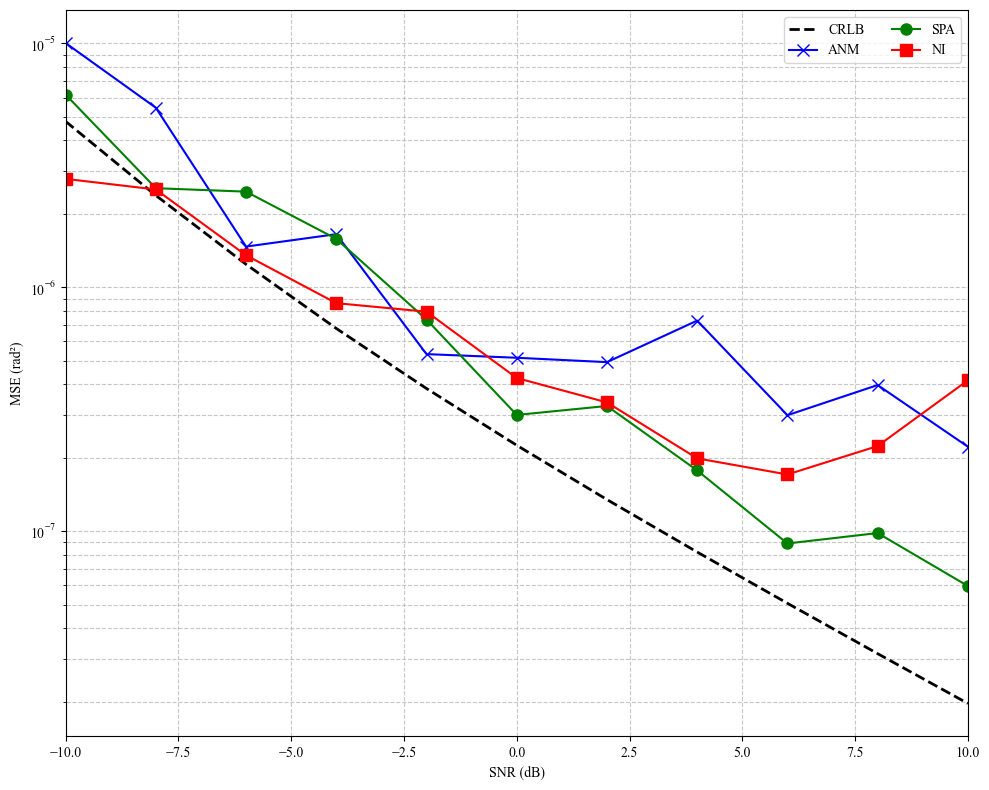

In [5]:
# Plot MSE vs SNR using our plotting tool
fig, ax = plt.subplots(figsize=(10, 8))
plt_tools.plot_metric_vs_parameter(
    parameter_values=snr_values,
    results={alg: snr_results[alg]['mse'] for alg in snr_results.keys()},
    parameter_name='SNR',
    metric_name='MSE',
    parameter_unit='dB',
    metric_unit='rad²',
    crb_label='CRLB',
    crb_values=crb_snr_values,
    show_crb=True,
    ax=ax
    )
plt.tight_layout()
plt.show()

## 7. CDF Comparison

In [4]:
# Let's generate scatter plots for all algorithms
# We'll use SNR=10 dB with 256 snapshots

print('Generating scatter plots for all algorithms...')

sample_snr = -5.0  # SNR in dB
sample_n_snapshots = 1024  # Number of snapshots
sample_n_monte_carlo = 1000  # Number of Monte Carlo runs for sample generation

# Run performance evaluation with save_sample_estimates=True
sample_result = perf.evaluate_performance(
    array=array,
    sources=sources,
    snr=sample_snr,
    n_snapshots=sample_n_snapshots,
    n_monte_carlo=sample_n_monte_carlo,
    estimators=estimators,
    metrics=['mse', 'bias'],
    save_sample_estimates=True,
    n_jobs=1,
    verbose=1
)

print(f'Generated sample estimates for: {list(sample_result.sample_estimates.keys())}')

Generating scatter plots for all algorithms...


Evaluating estimators: 100%|██████████| 3000/3000 [00:10<00:00, 276.31it/s]

Generated sample estimates for: ['DA', 'SS', 'NI']


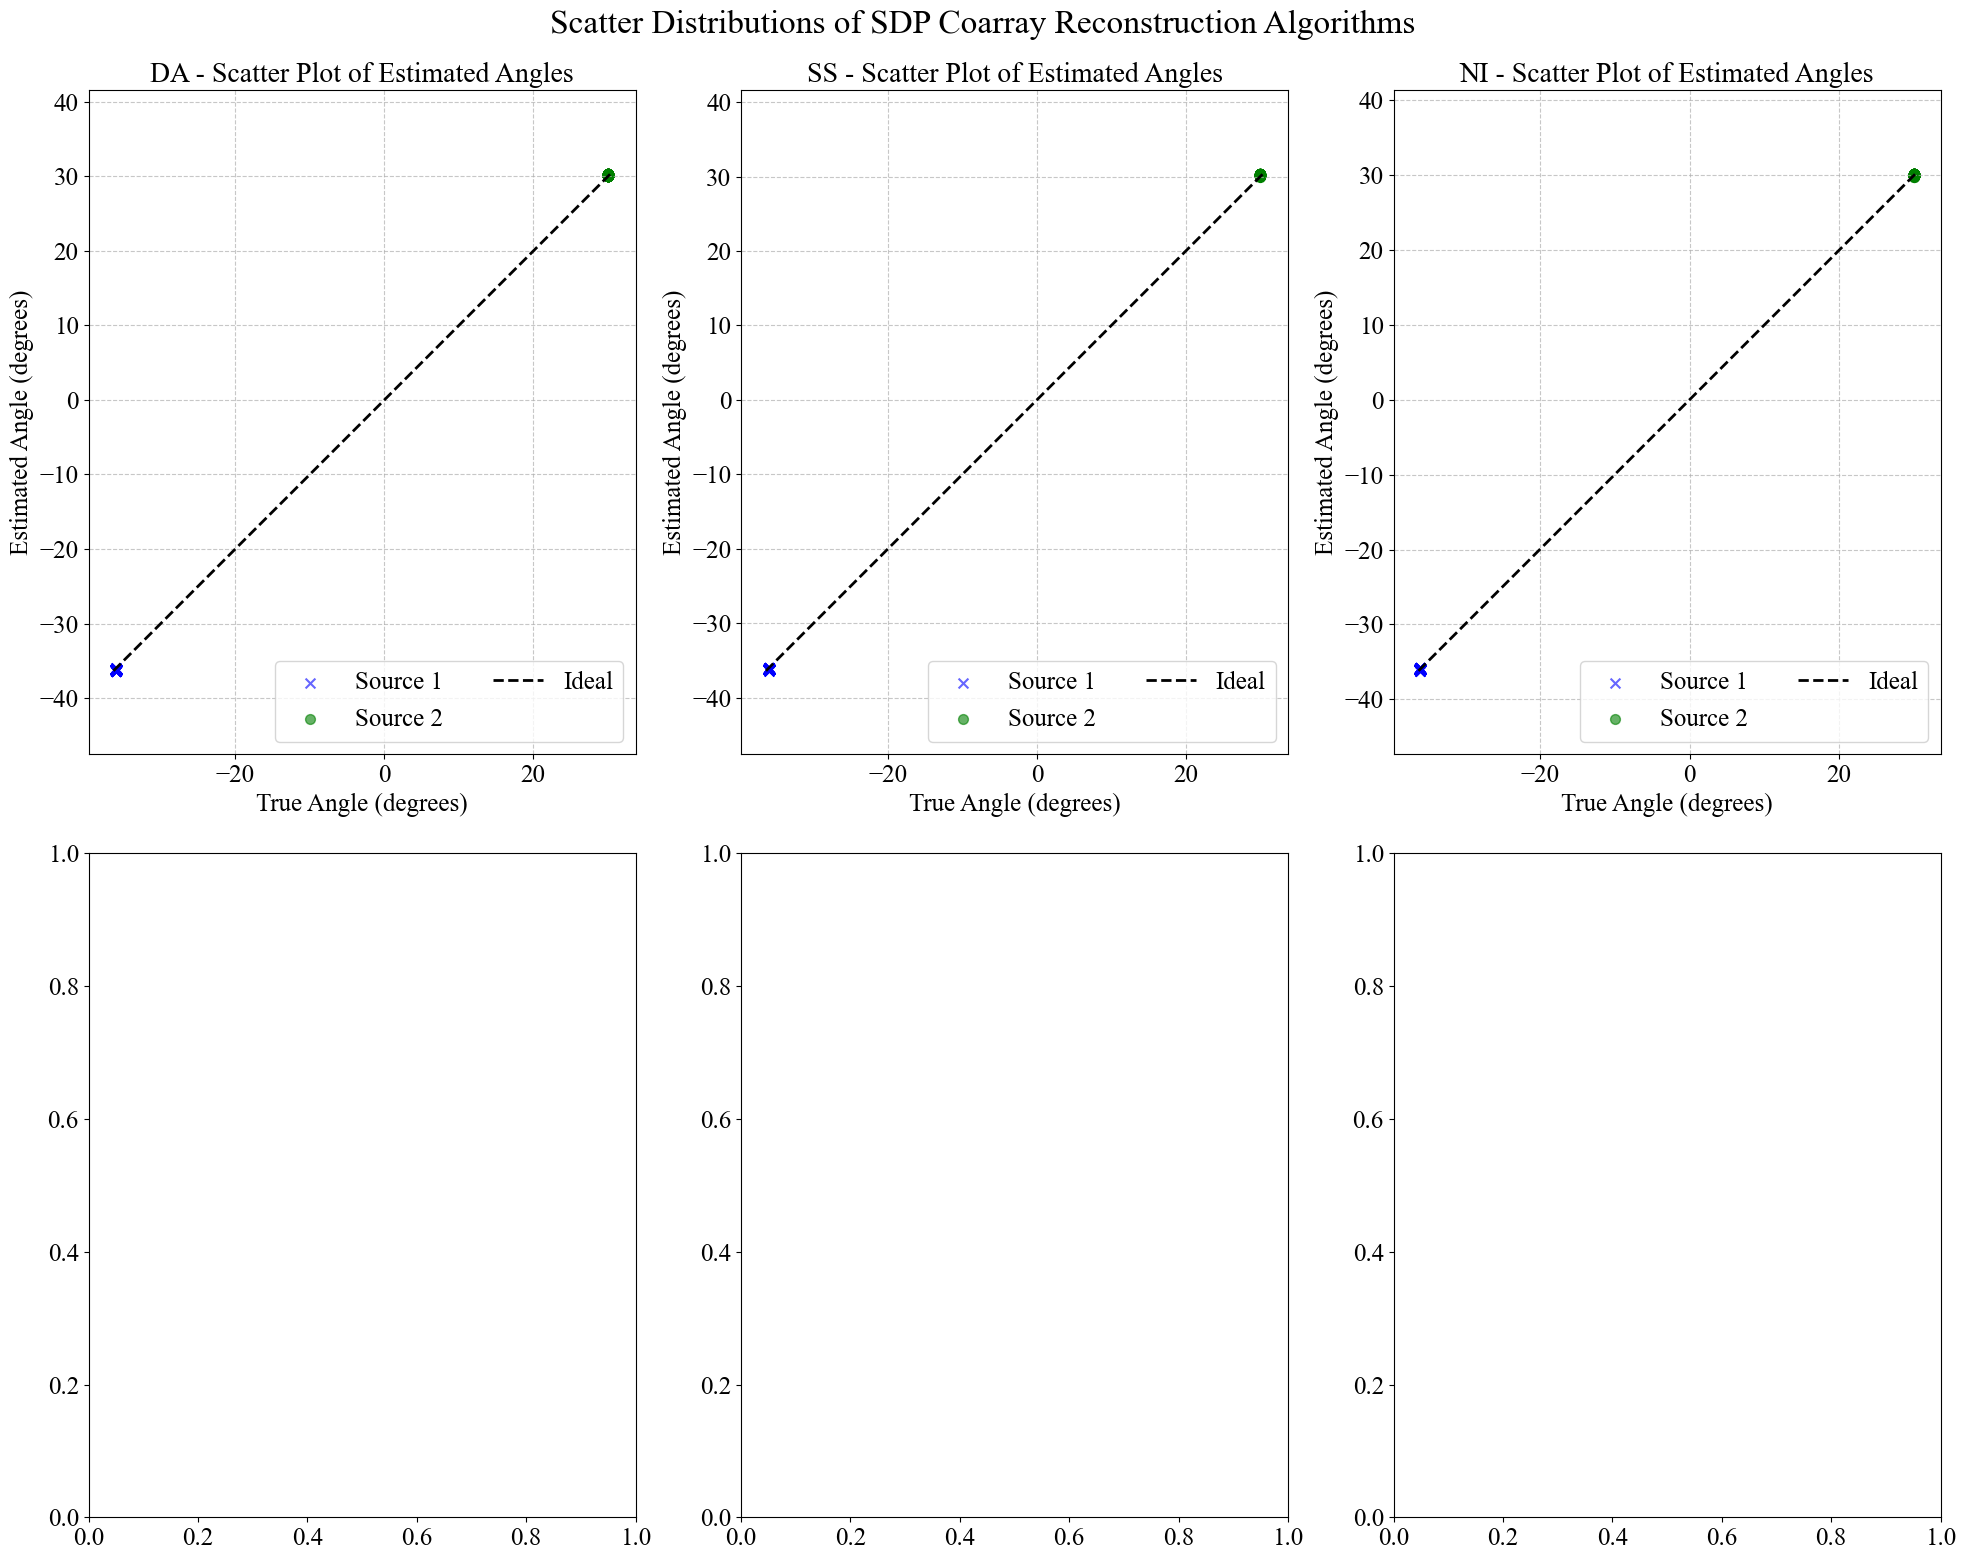

In [5]:
# Plot scatter plot for each algorithm
fig, axes = plt.subplots(2, 3, figsize=(20, 16))
axes = axes.flatten()

for i, (alg_name, estimates) in enumerate(sample_result.sample_estimates.items()):
    ax = axes[i]
    plt_tools.plot_scatter_estimates(
        true_angles=source_angles,
        estimates=estimates,
        algorithm_name=alg_name,
        angle_unit='deg',
        ax=ax
    )
    ax.set_title(f'{alg_name} - Scatter Plot of Estimated Angles', fontsize=20)

plt.suptitle('Scatter Distributions of SDP Coarray Reconstruction Algorithms', fontsize=24, y=0.98)
plt.tight_layout()
plt.show()

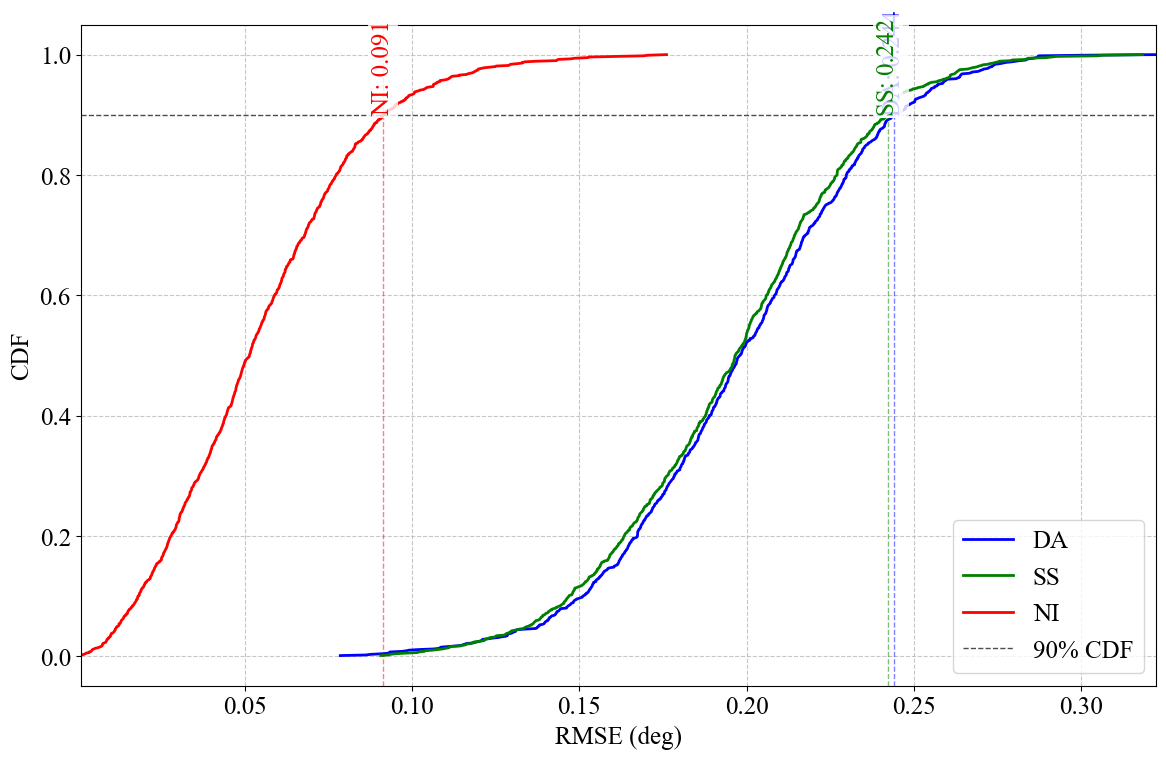

In [10]:
# Plot CDFs of RMS Error for all algorithms
fig, ax = plt.subplots(figsize=(12, 8))
plt_tools.plot_cdf(
    estimates=sample_result.sample_estimates,
    true_angles=source_angles,
    metric_name='RMSE',
    metric_unit='deg',
    metric_type='rms',
    ax=ax,
    show_90_percentile=True
)
# 添加90%的线

# plt.title('CDF of RMS Error for SDP Coarray Reconstruction Algorithms', fontsize=20)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Compute Time

In [16]:
sample_result.estimator_times

{'NI': np.float64(0.0024929380416870116)}